In [1]:
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from stn_gpe import run_closed_loop_DBS
import os

#### Ensemble of chaotic Rossler Oscillators

In [3]:
rng = np.random.default_rng(42)
mean = 1
std_dev = 0.02
N = 100
wk = rng.normal(loc=mean, scale=std_dev,size=N)

In [4]:
# Time Span
t_span = (0, 4000)
t_eval = np.arange(t_span[0], t_span[-1], 0.01)
dt = t_span[-1]/np.size(t_eval)

#### Charged Balanced Pulses

In [5]:
k = 0.45
G_X, P_a, theta, e_fb, t_0, G_Y, G_Z, x_10, y_10, z_10= run_closed_loop_DBS(100, t_eval, wk, 1000, 0.3*np.pi, 0.01, 0.005, 0.005, k)

Running closed loop DBS for k = 0.45
time =  0.0
time =  100.0
time =  200.0
time =  300.0
time =  400.0
time =  500.0
time =  600.0
time =  700.0
time =  800.0
time =  900.0
time =  1000.0
time =  1100.0
time =  1200.0
time =  1300.0
time =  1400.0
time =  1500.0
time =  1600.0
time =  1700.0
time =  1800.0
time =  1900.0
time =  2000.0
time =  2100.0
time =  2200.0
time =  2300.0
time =  2400.0
time =  2500.0
time =  2600.0
time =  2700.0
time =  2800.0
time =  2900.0
time =  3000.0
time =  3100.0
time =  3200.0
time =  3300.0
time =  3400.0
time =  3500.0
time =  3600.0
time =  3700.0
time =  3800.0
time =  3900.0


## Save data

In [10]:
folder_name = 'temp/closed_loop'
folder_path = os.path.join(project_root, folder_name)

# create a temp folder in root base folder
os.makedirs(folder_path, exist_ok=True)

np.savetxt(os.path.join(folder_path, 'X_mean_closedloop.txt'), G_X, delimiter=',') # Global X (Mean X)
np.savetxt(os.path.join(folder_path, 'Y_mean_closedloop.txt'), G_Y, delimiter=',') # Global Y (Mean Y)
np.savetxt(os.path.join(folder_path, 'Z_mean_closedloop.txt'), G_Z, delimiter=',') # Global Z (Mean Z)
np.savetxt(os.path.join(folder_path, 'DBS_pulses_closedloop.txt'), P_a, delimiter=',') # DBS pulses
np.savetxt(os.path.join(folder_path, 'theta_closedloop.txt'), theta, delimiter=',') # theta of Global X trend
np.savetxt(os.path.join(folder_path, 'E_fb_closedloop.txt'), e_fb, delimiter=',') # epsilon_bf trend
np.savetxt(os.path.join(folder_path, 'theta_0_closedloop.txt'), t_0, delimiter=',') # theta_0 trend
np.savetxt(os.path.join(folder_path, 'x_osc_closedloop.txt'), x_10[1:], delimiter=',') # x of 10 oscillators
np.savetxt(os.path.join(folder_path, 'y_osc_closedloop.txt'), y_10[1:], delimiter=',') # y of 10 oscillators
np.savetxt(os.path.join(folder_path, 'z_osc_closedloop.txt'), z_10[1:], delimiter=',') # z of 10 oscillators



## Load data

In [11]:
Pulses = np.loadtxt(os.path.join(folder_path, 'DBS_pulses_closedloop.txt'), delimiter=',')
X = np.loadtxt(os.path.join(folder_path, 'X_mean_closedloop.txt'), delimiter=',')
ep_fb = np.loadtxt(os.path.join(folder_path, 'E_fb_closedloop.txt'), delimiter=',')
theta_0 = np.loadtxt(os.path.join(folder_path, 'theta_0_closedloop.txt'), delimiter=',')

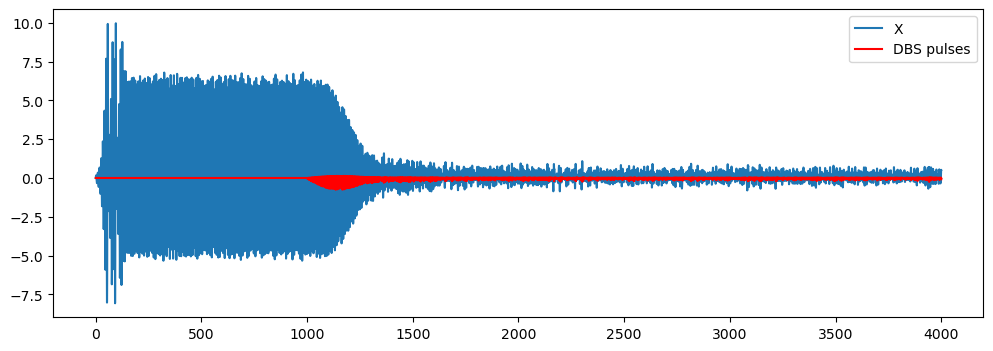

In [12]:
plt.figure(figsize = (12, 4))
plt.plot(t_eval, X, label = 'X', color = 'tab:blue')
plt.plot(t_eval, Pulses, label = 'DBS pulses', color = 'red')
plt.legend()

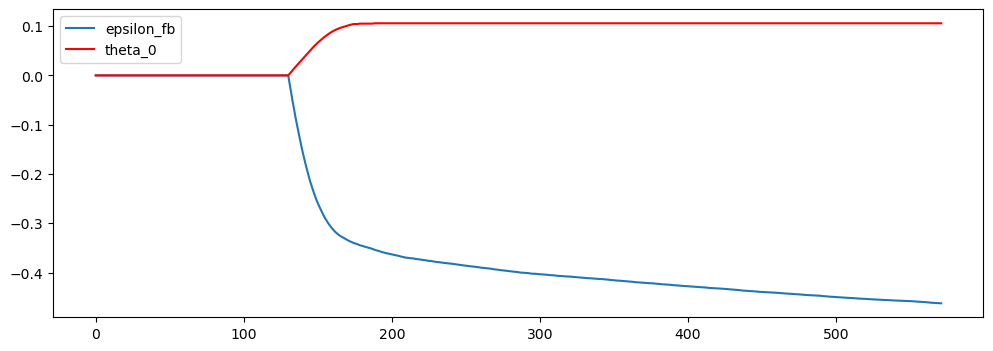

In [15]:
plt.figure(figsize = (12, 4))
plt.plot(ep_fb, label = 'epsilon_fb', color = 'tab:blue')
plt.plot(theta_0, label = 'theta_0', color = 'red')
plt.legend()